In [ ]:
import os
import cv2
import numpy as np
import random
import glob

class DatasetAugmentor:
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.class_counts = {}

    def count_images_per_class(self):
        """Count images in each class folder"""
        for class_name in os.listdir(self.dataset_path):
            class_path = os.path.join(self.dataset_path, class_name)
            if os.path.isdir(class_path):
                image_files = [f for f in os.listdir(class_path)
                             if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                self.class_counts[class_name] = len(image_files)

        print("Current class distribution:")
        for class_name, count in self.class_counts.items():
            print(f"{class_name}: {count} images")
        return self.class_counts

    def rotate_image_white_padding(self, image, angle_range=(-10, 10)):
        """Rotate image by random angle with white padding"""
        angle = random.uniform(angle_range[0], angle_range[1])
        rows, cols = image.shape[:2]

        # for calutating rotation matrix
        M = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)

        # Applying rotation with white background
        rotated = cv2.warpAffine(image, M, (cols, rows), borderValue=(255, 255, 255))

        return rotated

    def augment_class(self, class_name, class_path, current_count):
        # Augmenting images for a specific class based on count"""
        print(f"\nProcessing class '{class_name}' with {current_count} images...")

        image_files = glob.glob(os.path.join(class_path, "*.png")) + \
                     glob.glob(os.path.join(class_path, "*.jpg")) + \
                     glob.glob(os.path.join(class_path, "*.jpeg"))

        if current_count >= 600:
            # Take 30 random images and augment them
            selected_files = random.sample(image_files, min(200, len(image_files)))
            target_augs = 200
            print(f"  Strategy: Augmenting 30 random images from {current_count}")

        elif current_count >= 320:
            # Create 1x copy (same number of augmented images as original)
            target_augs = current_count
            selected_files = image_files.copy()
            print(f"  Strategy: Creating {target_augs} augmented images (1x copy)")

        elif current_count >= 150:
            target_augs = current_count * 3
            selected_files = image_files * 3
            print(f"  Strategy: Creating {target_augs} augmented images (3x)")

        else:
            target_augs = max(400, current_count * 5)
            multiplier = target_augs // current_count + 1
            selected_files = image_files * multiplier
            selected_files = selected_files[:target_augs]
            print(f"  Strategy: Creating {target_augs} augmented images (targeting 400+)")

        aug_count = 0
        for i, img_path in enumerate(selected_files):
            try:
                if img_path.lower().endswith('.png'):
                    image = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
                else:
                    image = cv2.imread(img_path)

                if image is None:
                    continue

                rotated = self.rotate_image_white_padding(image)

                base_name = os.path.splitext(os.path.basename(img_path))[0]
                ext = os.path.splitext(img_path)[1]
                aug_filename = f"{base_name}_rot_{i}{ext}"
                aug_path = os.path.join(class_path, aug_filename)

                cv2.imwrite(aug_path, rotated)
                aug_count += 1

                if aug_count % 50 == 0:
                    print(f"  Processed {aug_count}/{len(selected_files)} images")

            except Exception as e:
                print(f"  Error processing {img_path}: {e}")
                continue

        print(f"  Completed: Added {aug_count} augmented images")
        return aug_count

    def augment_dataset(self):
        """Augment the entire dataset"""
        print("Starting dataset augmentation with rotation only...")

        self.count_images_per_class()

        total_added = 0

        for class_name, count in self.class_counts.items():
            class_path = os.path.join(self.dataset_path, class_name)

            if not os.path.isdir(class_path):
                continue

            added = self.augment_class(class_name, class_path, count)
            total_added += added

        print(f"\n=== Augmentation Complete ===")
        print(f"Total images added: {total_added}")

        print("\nFinal class distribution:")
        self.count_images_per_class()


dataset_path = "/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/char_dataset-english-labels"  # Change this 

augmentor = DatasetAugmentor(dataset_path)

augmentor.augment_dataset()

Starting dataset augmentation with rotation only...
Current class distribution:
ko: 18 images
khulna: 21 images
no: 38 images
po: 12 images
lo: 194 images
sylhet: 7 images
metro: 305 images
tto: 7 images
maimanshing: 7 images
to: 22 images
bo: 29 images
kho: 14 images
dhaka: 323 images
9: 329 images
ho: 186 images
chattro: 74 images
cho: 40 images
do: 14 images
gha: 17 images
ga: 207 images
7: 406 images
6: 358 images
1: 612 images
2: 446 images
3: 413 images
0: 408 images
4: 414 images
5: 413 images
8: 401 images

Processing class 'ko' with 18 images...
  Strategy: Creating 400 augmented images (targeting 400+)
  Processed 50/400 images
  Processed 100/400 images
  Processed 150/400 images
  Processed 200/400 images
  Processed 250/400 images
  Processed 300/400 images
  Processed 350/400 images
  Processed 400/400 images
  Completed: Added 400 augmented images

Processing class 'khulna' with 21 images...
  Strategy: Creating 400 augmented images (targeting 400+)
  Processed 50/400 im

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)


In [ ]:
def preprocess_contour_image(img, target_size=(64, 64)):
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    img = cv2.resize(img, target_size)
    img_3ch = np.stack([img] * 3, axis=-1)
    return img_3ch


In [ ]:
dataset_path = '/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/char_dataset-english-labels'
img_size = (64, 64)

class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
print(f"Found {len(class_names)} classes: {class_names}")

images = []
labels = []

for class_idx, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Loading {len(image_files)} images from class '{class_name}'")

    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = preprocess_contour_image(img, img_size)
                images.append(img)
                labels.append(class_idx)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

images = np.array(images, dtype=np.float32) / 255.0
labels = np.array(labels)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, random_state=42, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")


In [ ]:
def preprocess_contour_image(self, img):
    # steps performed here:
    # 1. Load as grayscale
    # 2. Convert to 3-channel for EfficientNet compatibility
    # 3. Normalize to [0, 1]

    if len(img.shape) == 3:
        # If RGB, convert to grayscale first
        img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Ensure it's 64x64 (should already be from your pipeline)
    img = cv2.resize(img, self.img_size)

    # Converting single channel to 3-channel for EfficientNet
    img_3ch = np.stack([img, img, img], axis=-1)

    return img_3ch

In [ ]:
class BengaliOCRTrainer:
    def __init__(self, dataset_path, img_size=(64, 64), batch_size=32):
        self.dataset_path = dataset_path
        self.img_size = img_size
        self.batch_size = batch_size
        self.model = None
        self.class_names = []
        self.history = None

    def load_and_preprocess_data(self):
        """Load and preprocess the dataset"""
        print("Loading and preprocessing data...")

        # extracing class names from directory structure
        self.class_names = sorted([d for d in os.listdir(self.dataset_path)
                                 if os.path.isdir(os.path.join(self.dataset_path, d))])

        print(f"Found {len(self.class_names)} classes: {self.class_names}")

        # Load images and labels
        images = []
        labels = []

        for class_idx, class_name in enumerate(self.class_names):
            class_path = os.path.join(self.dataset_path, class_name)
            image_files = [f for f in os.listdir(class_path)
                          if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            print(f"Loading {len(image_files)} images from class '{class_name}'")

            for img_file in image_files:
                img_path = os.path.join(class_path, img_file)
                try:
                    # Load image (your images are already grayscale from contour extraction)
                    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                    if img is not None:
                        # Apply the same preprocessing as your contour pipeline
                        img = self.preprocess_contour_image(img)
                        images.append(img)
                        labels.append(class_idx)
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")

        # Convert to numpy arrays and normalize
        images = np.array(images, dtype=np.float32) / 255.0
        labels = np.array(labels)

        print(f"Total images loaded: {len(images)}")
        print(f"Image shape: {images.shape}")
        print(f"Labels shape: {labels.shape}")

        return images, labels

    def create_data_generators(self, X_train, y_train, X_val, y_val):
        """Create data generators with augmentation"""

        # Data augmentation for training - optimized for binary text images
        train_datagen = ImageDataGenerator(
            rotation_range=5,  # Reduced rotation for text
            width_shift_range=0.05,  # Reduced shifts for precise character positioning
            height_shift_range=0.05,
            shear_range=0.05,  # Reduced shear for text
            zoom_range=0.05,  # Reduced zoom for text
            horizontal_flip=False,  # Never flip text
            fill_mode='constant',  # Use constant fill (white background)
            cval=1.0,  # Fill with white (since normalized to [0,1])
            # Remove brightness and channel shift as these are binary images
        )

        # No augmentation for validation
        val_datagen = ImageDataGenerator()

        # Convert labels to categorical
        y_train_cat = keras.utils.to_categorical(y_train, num_classes=len(self.class_names))
        y_val_cat = keras.utils.to_categorical(y_val, num_classes=len(self.class_names))

        # Create generators
        train_generator = train_datagen.flow(
            X_train, y_train_cat,
            batch_size=self.batch_size,
            shuffle=True
        )

        val_generator = val_datagen.flow(
            X_val, y_val_cat,
            batch_size=self.batch_size,
            shuffle=False
        )

        return train_generator, val_generator, y_train_cat, y_val_cat

    def build_model(self):
        """Build the CNN model using EfficientNet-B0 as base"""
        print("Building model...")

        # Create base model
        base_model = EfficientNetB0(
            weights='imagenet',
            include_top=False,
            input_shape=(*self.img_size, 3),
            pooling='avg'
        )

        # Freeze base model layers initially
        base_model.trainable = False

        # Add custom classification head
        model = keras.Sequential([
            base_model,
            layers.Dropout(0.5),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(len(self.class_names), activation='softmax')
        ])

        # Compile model
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss='categorical_crossentropy',
            metrics=['accuracy'] # Removed 'top_2_accuracy'
        )

        self.model = model
        print(f"Model built with {len(self.class_names)} output classes")
        return model

    def train_model(self, train_generator, val_generator, epochs=35):
        """Train the model with callbacks"""
        print("Starting training...")

        # Callbacks
        callbacks = [
            EarlyStopping(
                monitor='val_accuracy',
                patience=10,
                restore_best_weights=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=5,
                min_lr=1e-7,
                verbose=1
            ),
            ModelCheckpoint(
                'best_bengali_ocr_model.h5',
                monitor='val_accuracy',
                save_best_only=True,
                save_weights_only=False,
                verbose=1
            )
        ]

        # Train the model
        history = self.model.fit(
            train_generator,
            epochs=epochs,
            validation_data=val_generator,
            callbacks=callbacks,
            verbose=1
        )

        self.history = history

        # Fine-tune the model
        print("\nFine-tuning the model...")
        self.fine_tune_model(train_generator, val_generator)

        return history

    def fine_tune_model(self, train_generator, val_generator, fine_tune_epochs=65):
        """Fine-tune the pretrained layers"""

        # Unfreeze the base model
        self.model.layers[0].trainable = True

        # Recompile with lower learning rate
        self.model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy'] # Removed 'top_2_accuracy'
        )

        # Continue training
        fine_tune_history = self.model.fit(
            train_generator,
            epochs=fine_tune_epochs,
            validation_data=val_generator,
            callbacks=[
                EarlyStopping(
                    monitor='val_accuracy',
                    patience=5,
                    restore_best_weights=True
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=0.5,
                    patience=3,
                    min_lr=1e-8,
                    verbose=1
                )
            ],
            verbose=1
        )

        # Append fine-tuning history
        for key in self.history.history.keys():
            self.history.history[key].extend(fine_tune_history.history[key])


    def evaluate_model(self, X_test, y_test):
        """Evaluate the model and show metrics"""
        print("Evaluating model...")

        # Predictions
        y_pred_prob = self.model.predict(X_test)
        y_pred = np.argmax(y_pred_prob, axis=1)

        # Calculate accuracy
        test_accuracy = np.mean(y_pred == y_test)
        print(f"Test Accuracy: {test_accuracy:.4f}")

        # Classification report
        print("\nClassification Report:")
        report = classification_report(y_test, y_pred, target_names=self.class_names)
        print(report)

        # Confusion matrix
        self.plot_confusion_matrix(y_test, y_pred)

        # Per-class accuracy
        self.plot_per_class_accuracy(y_test, y_pred)

        return test_accuracy, y_pred, y_pred_prob

    def plot_confusion_matrix(self, y_true, y_pred):
        """Plot confusion matrix"""
        cm = confusion_matrix(y_true, y_pred)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=self.class_names,
                    yticklabels=self.class_names)
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    def plot_per_class_accuracy(self, y_true, y_pred):
        """Plot per-class accuracy"""
        per_class_acc = []
        for i, class_name in enumerate(self.class_names):
            mask = y_true == i
            if np.sum(mask) > 0:
                acc = np.mean(y_pred[mask] == y_true[mask])
                per_class_acc.append(acc)
            else:
                per_class_acc.append(0)

        plt.figure(figsize=(15, 6))
        bars = plt.bar(range(len(self.class_names)), per_class_acc)
        plt.xlabel('Classes')
        plt.ylabel('Accuracy')
        plt.title('Per-Class Accuracy')
        plt.xticks(range(len(self.class_names)), self.class_names, rotation=45)
        plt.ylim(0, 1)

        # Add value labels on bars
        for bar, acc in zip(bars, per_class_acc):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom')

        plt.tight_layout()
        plt.show()

    def plot_training_history(self):
        """Plot training history"""
        if self.history is None:
            print("No training history available")
            return

        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Accuracy
        axes[0, 0].plot(self.history.history['accuracy'], label='Training Accuracy')
        axes[0, 0].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
        axes[0, 0].set_title('Model Accuracy')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Accuracy')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        # Loss
        axes[0, 1].plot(self.history.history['loss'], label='Training Loss')
        axes[0, 1].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[0, 1].set_title('Model Loss')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True)

        # Top-2 Accuracy (if available)
        if 'top_2_accuracy' in self.history.history:
            axes[1, 0].plot(self.history.history['top_2_accuracy'], label='Training Top-2 Accuracy')
            axes[1, 0].plot(self.history.history['val_top_2_accuracy'], label='Validation Top-2 Accuracy')
            axes[1, 0].set_title('Top-2 Accuracy')
            axes[1, 0].set_xlabel('Epoch')
            axes[1, 0].set_ylabel('Top-2 Accuracy')
            axes[1, 0].legend()
            axes[1, 0].grid(True)
        else:
            axes[1, 0].text(0.5, 0.5, 'Top-2 Accuracy\nNot Available',
                          ha='center', va='center', transform=axes[1, 0].transAxes)


        # Learning rate (if available)
        if 'lr' in self.history.history:
            axes[1, 1].plot(self.history.history['lr'])
            axes[1, 1].set_title('Learning Rate')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Learning Rate')
            axes[1, 1].set_yscale('log')
            axes[1, 1].grid(True)
        else:
            axes[1, 1].text(0.5, 0.5, 'Learning Rate\nNot Available',
                          ha='center', va='center', transform=axes[1, 1].transAxes)

        plt.tight_layout()
        plt.show()

    def create_inference_preprocessing_function(self):
        """
        Create a preprocessing function that matches your contour extraction pipeline.
        Use this function when making predictions on new contour images.
        """
        def preprocess_for_inference(contour_image):
            """
            Preprocess a single contour image for inference.
            Input: 64x64 grayscale image from your contour extraction pipeline
            Output: Preprocessed image ready for model prediction
            """
            # Ensure it's the right size
            if contour_image.shape != (64, 64):
                contour_image = cv2.resize(contour_image, (64, 64))

            # Convert to 3-channel for EfficientNet
            if len(contour_image.shape) == 2:
                img_3ch = np.stack([contour_image, contour_image, contour_image], axis=-1)
            else:
                img_3ch = contour_image

            # Normalize to [0, 1]
            img_3ch = img_3ch.astype(np.float32) / 255.0

            # Add batch dimension
            img_batch = np.expand_dims(img_3ch, axis=0)

            return img_batch

        return preprocess_for_inference

    def predict_sample_images(self, X_test, y_test, num_samples=10):
        """Show predictions on sample images"""
        # Get random samples
        indices = np.random.choice(len(X_test), num_samples, replace=False)

        # Make predictions
        sample_images = X_test[indices]
        sample_labels = y_test[indices]
        predictions = self.model.predict(sample_images)
        predicted_classes = np.argmax(predictions, axis=1)

        # Plot results
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))
        axes = axes.ravel()

        for i in range(num_samples):
            axes[i].imshow(sample_images[i])
            axes[i].set_title(f'True: {self.class_names[sample_labels[i]]}\n'
                            f'Pred: {self.class_names[predicted_classes[i]]}\n'
                            f'Conf: {predictions[i][predicted_classes[i]]:.3f}')
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

Loading and preprocessing data...
Found 29 classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'bo', 'chattro', 'cho', 'dhaka', 'do', 'ga', 'gha', 'ho', 'kho', 'khulna', 'ko', 'lo', 'maimanshing', 'metro', 'no', 'po', 'sylhet', 'to', 'tto']
Loading 816 images from class '0'
Loading 812 images from class '1'
Loading 892 images from class '2'
Loading 826 images from class '3'
Loading 828 images from class '4'
Loading 826 images from class '5'
Loading 716 images from class '6'
Loading 812 images from class '7'
Loading 802 images from class '8'
Loading 658 images from class '9'
Loading 429 images from class 'bo'
Loading 474 images from class 'chattro'
Loading 440 images from class 'cho'
Loading 646 images from class 'dhaka'
Loading 414 images from class 'do'
Loading 828 images from class 'ga'
Loading 417 images from class 'gha'
Loading 744 images from class 'ho'
Loading 414 images from class 'kho'
Loading 421 images from class 'khulna'
Loading 418 images from class 'ko'
Loading 776

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,680 (16.84 MB)

 Trainable params: 365,341 (1.39 MB)

...

397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.0932 - loss: 3.2158 - val_accuracy: 0.1898 - val_loss: 3.0030 - learning_rate: 0.0010
Epoch 8/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.0955 - loss: 3.2091
Epoch 8: val_accuracy did not improve from 0.18985
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.0955 - loss: 3.2091 - val_accuracy: 0.1431 - val_loss: 2.9828 - learning_rate: 0.0010
Epoch 9/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.0957 - loss: 3.2036
Epoch 9: val_accuracy improved from 0.18985 to 0.21155, saving model to best_bengali_ocr_model.h5


397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.0957 - loss: 3.2036 - val_accuracy: 0.2116 - val_loss: 2.9654 - learning_rate: 0.0010
Epoch 10/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1040 - loss: 3.1876
Epoch 10: val_accuracy did not improve from 0.21155
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1040 - loss: 3.1876 - val_accuracy: 0.2001 - val_loss: 2.9495 - learning_rate: 0.0010
Epoch 11/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1020 - loss: 3.1761
Epoch 11: val_accuracy did not improve from 0.21155
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1020 - loss: 3.1761 - val_accuracy: 0.1328 - val_loss: 3.0044 - learning_rate: 0.0010
Epoch 12/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.0962 - loss: 3.1699
Epoch 12: val_accuracy did not improve from 0.21155
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.0962 - loss: 3.1699 - val_accuracy: 0.1608 - val_loss: 2.9306 - learning_rate: 0.0010
Epoch 13

397/397 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.1070 - loss: 3.1358 - val_accuracy: 0.2583 - val_loss: 2.8529 - learning_rate: 0.0010
Epoch 17/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1123 - loss: 3.1357
Epoch 17: val_accuracy did not improve from 0.25828
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1123 - loss: 3.1357 - val_accuracy: 0.2020 - val_loss: 2.8398 - learning_rate: 0.0010
Epoch 18/50
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1070 - loss: 3.1428
Epoch 18: val_accuracy did not improve from 0.25828
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.1070 - loss: 3.1428 - val_accuracy: 0.2421 - val_loss: 2.8355 - learning_rate: 0.0010
Epoch 19/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1166 - loss: 3.1225
Epoch 19: val_accuracy did not improve from 0.25828
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.1166 - loss: 3.1225 - val_accuracy: 0.2163 - val_loss: 2.8261 - learning_rate: 0.0010
Epoch 20

397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.1152 - loss: 3.1247 - val_accuracy: 0.2734 - val_loss: 2.8251 - learning_rate: 0.0010
Epoch 23/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1167 - loss: 3.1114
Epoch 23: val_accuracy did not improve from 0.27336
397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1167 - loss: 3.1114 - val_accuracy: 0.2182 - val_loss: 2.8651 - learning_rate: 0.0010
Epoch 24/50
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1197 - loss: 3.1033
Epoch 24: val_accuracy did not improve from 0.27336
397/397 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - accuracy: 0.1197 - loss: 3.1033 - val_accuracy: 0.2038 - val_loss: 2.8217 - learning_rate: 0.0010
Epoch 25/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1231 - loss: 3.1181
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 25: val_accuracy did not improve from 0.27336
397/397 ━━━━━━━━━━━━━━━━━━━━ 21s 53ms/step - accuracy: 0.1230 - loss: 3.

397/397 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.1230 - loss: 3.0846 - val_accuracy: 0.2987 - val_loss: 2.7655 - learning_rate: 2.0000e-04
Epoch 29/50
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1241 - loss: 3.0775
Epoch 29: val_accuracy did not improve from 0.29875
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.1241 - loss: 3.0775 - val_accuracy: 0.2723 - val_loss: 2.7599 - learning_rate: 2.0000e-04
Epoch 30/50
397/397 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.1185 - loss: 3.0801
Epoch 30: val_accuracy did not improve from 0.29875
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 49ms/step - accuracy: 0.1185 - loss: 3.0801 - val_accuracy: 0.2896 - val_loss: 2.7643 - learning_rate: 2.0000e-04
Epoch 31/50
396/397 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1208 - loss: 3.0652
Epoch 31: val_accuracy did not improve from 0.29875
397/397 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - accuracy: 0.1208 - loss: 3.0652 - val_accuracy: 0.2590 - val_loss: 2.7599 - learning_rate: 2.0

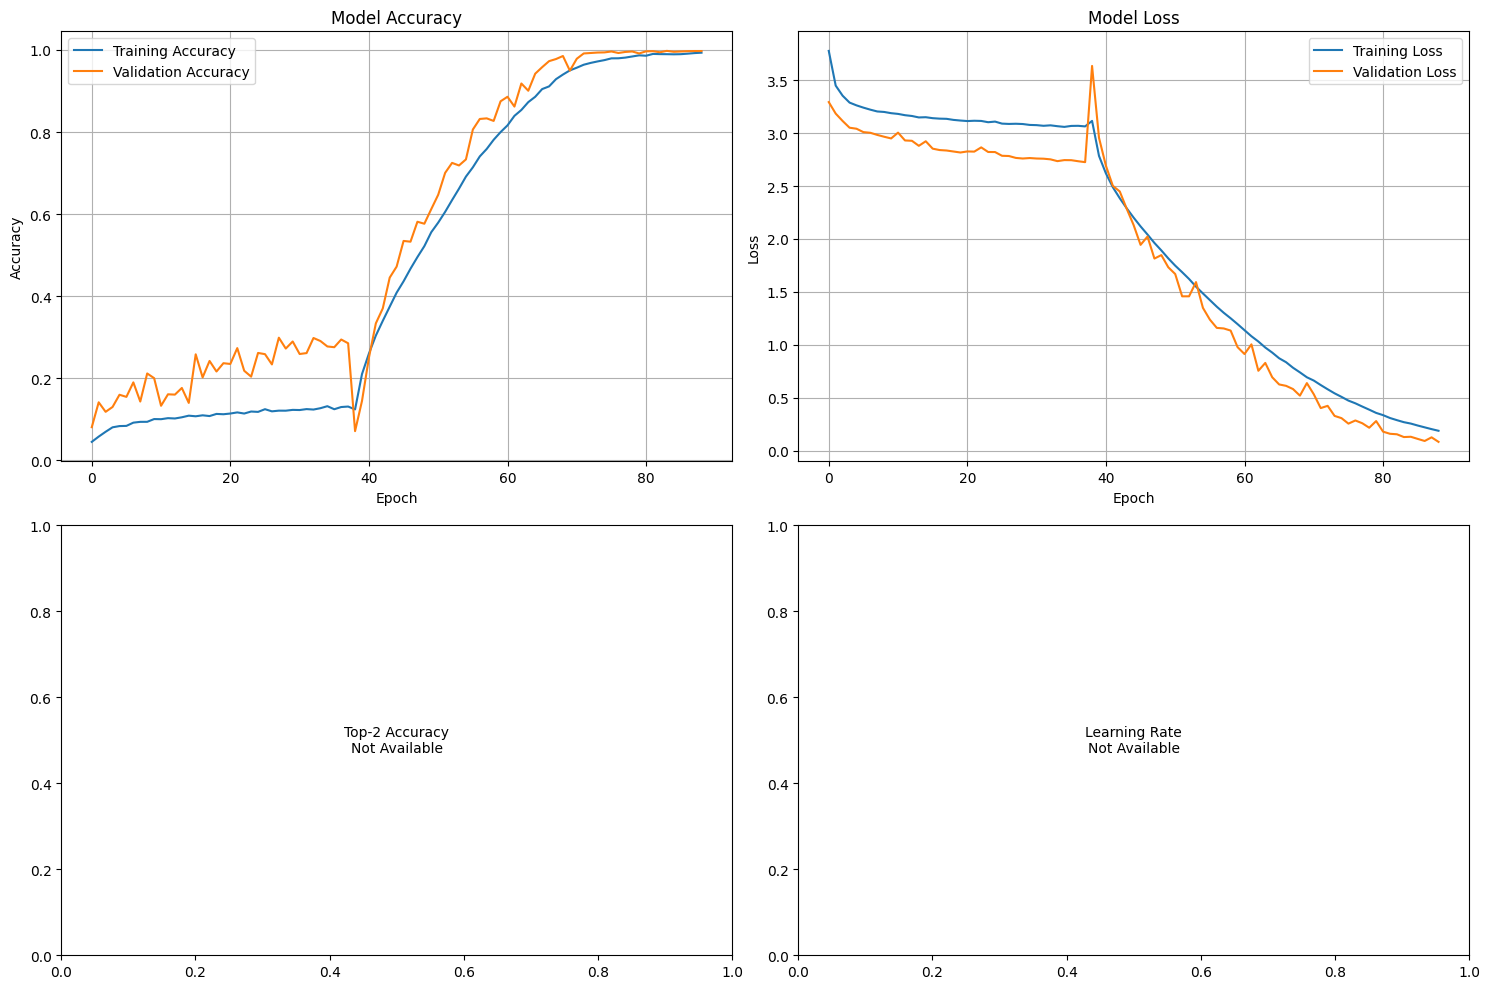

Evaluating model...
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step
Test Accuracy: 0.9974

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       0.99      0.97      0.98       122
           2       0.98      0.99      0.99       134
           3       1.00      1.00      1.00       124
           4       1.00      1.00      1.00       124
           5       1.00      1.00      1.00       124
           6       1.00      1.00      1.00       108
           7       1.00      1.00      1.00       122
           8       1.00      1.00      1.00       121
           9       0.98      1.00      0.99        99
          bo       1.00      1.00      1.00        64
     chattro       1.00      1.00      1.00        71
         cho       1.00      1.00      1.00        66
       dhaka       0.99      1.00      0.99        97
          do       1.00      1.00      1.00        62
          ga       1.00     

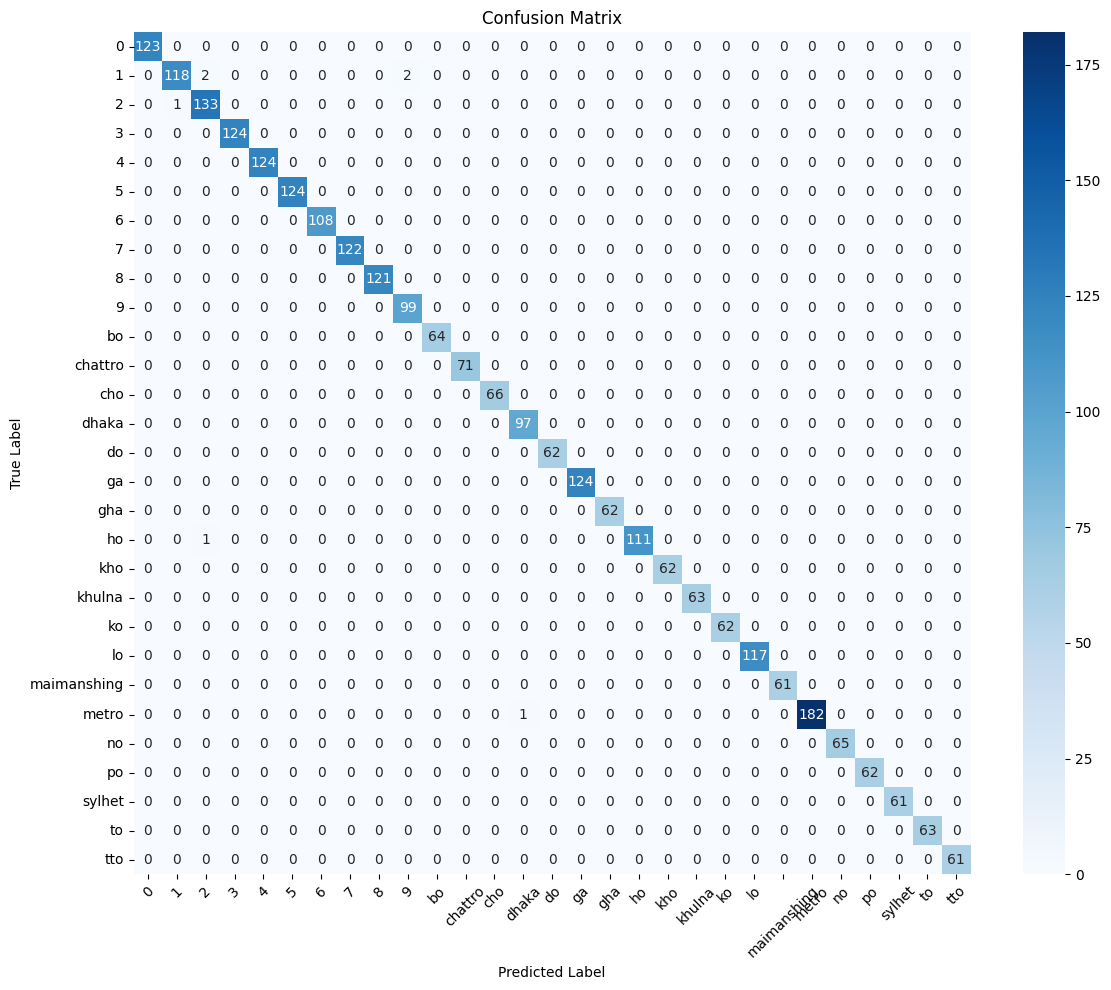

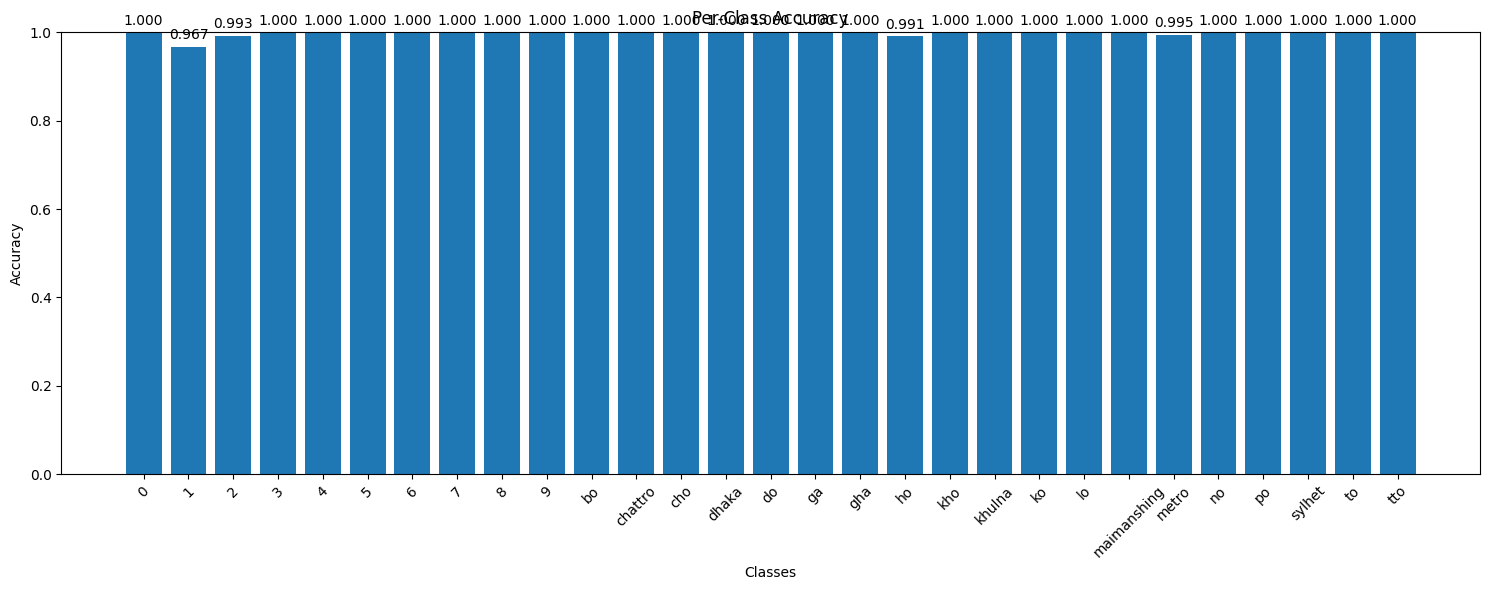

test accuracy:  0.9974255240897388


In [3]:
 # Initialize trainer
trainer = BengaliOCRTrainer(
    dataset_path='/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/char_dataset-english-labels',
    img_size=(64, 64),
    batch_size=32
)

# Load and preprocess data
images, labels = trainer.load_and_preprocess_data()

# Split data
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.3, random_state=42, stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Create data generators
train_gen, val_gen, y_train_cat, y_val_cat = trainer.create_data_generators(
    X_train, y_train, X_val, y_val
)

# Build and train model
trainer.build_model()
trainer.model.summary()

# Train the model
history = trainer.train_model(train_gen, val_gen, epochs=50)

# Plot training history
trainer.plot_training_history()

# Evaluate model
test_accuracy, y_pred, y_pred_prob = trainer.evaluate_model(X_test, y_test)

print("test accuracy: ", test_accuracy)

In [4]:
trainer.model.save('/content/drive/MyDrive/datasets/test-yolo-2-4-annotations/EfficientNetB0_license_plate_v2.keras')